In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import sys

In [2]:
# Add src/ directory to Python path
sys.path.append(os.path.abspath('../src'))

In [3]:
# Set a unified Seaborn theme with a single palette
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis", 2)  # Two colors: one for training loss, one for evaluation loss


In [5]:
def setup_directory(path):
    """
    Creates a directory if it doesn't exist.
    If it exists, clears all its contents.
    """
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)
    print(f"Directory '{path}' is set up.")

# Define directories for saving plots
loss_plots_dir = 'outputs/plots/loss_plots'
metric_plots_dir = 'output/plots/metric_plots'

# Set up directories
setup_directory(loss_plots_dir)
setup_directory(metric_plots_dir)

Directory 'outputs/plots/loss_plots' is set up.
Directory 'output/plots/metric_plots' is set up.


In [3]:
# Define data for Bert
bert_data = {
    'epoch': list(range(1, 13)),  # 12 data points
    'train_loss': [1.62308383, 0.208778381, 0.486358017, 0.258508235, 0.376719058, 
                   0.332781434, 0.012895919, 0.11387217, 0.097581953, 
                   0.017154945, 0.154288962, 0.036345538],
    'eval_loss': [1.121290796, 0.625999709, 0.496119322, 0.501466343, 0.487729639, 
                 0.496827833, 0.519962912, 0.528407477, 0.58433162, 
                 0.580247443, 0.608025825, 0.630409497]
}

# Define data for Gbert
gbert_data = {
    'epoch': list(range(1, 12)),  # 11 data points
    'train_loss': [3.002904654, 1.466436625, 0.923696816, 0.38424173, 0.705513656, 
                   0.30859977, 0.7550174, 0.690671742, 0.886532485, 0.895273685, 0.87731576],
    'eval_loss': [2.839948384, 1.176563262, 0.723421735, 0.573648225, 0.514057358, 
                 0.470669453, 0.906905822, 0.826417491, 0.775585076, 0.717706715, 0.704125887]
}

# Define data for Xlmroberta Base
xlmroberta_base_data = {
    'epoch': list(range(1, 12)),  # 11 data points
    'train_loss': [2.311267614, 0.758007348, 0.681797266, 0.466911167, 0.506454408, 
                   0.579205871, 0.158869132, 0.116305649, 0.114042521, 0.026775593, 0.274546802],
    'eval_loss': [2.140627145, 0.88315523, 0.633680997, 0.539821863, 0.459052306, 
                 0.442810608, 0.455075365, 0.407496348, 0.415866928, 0.420175505, 0.434275742]
}

# Define data for XLM RoBERTa Large
xlm_roberta_large_data = {
    'epoch': list(range(1, 18)),  # 17 data points (will map up to epoch 15)
    'train_loss': [2.155217886, 0.617424011, 0.469875634, 0.332166672, 0.659036756, 
                   0.217239827, 0.111112662, 0.114269242, 0.224804431, 0.204170495, 
                   0.054595049, 0.225057021, 0.503520191, 0.073787995, 0.045062792, 
                   0.13992469, 0.027861547],
    'eval_loss': [1.961650779, 0.765725688, 0.568471815, 0.50303094, 0.420132285, 
                 0.442615284, 0.376320244, 0.394084901, 0.406229009, 0.435831715, 
                 0.448692202, 0.456237623, 0.430396421, 0.456794968, 0.462042291, 
                 0.499137949, 0.482893051]
}


In [4]:
# Create DataFrames
bert_df = pd.DataFrame(bert_data)
gbert_df = pd.DataFrame(gbert_data)
xlmroberta_base_df = pd.DataFrame(xlmroberta_base_data)
xlm_roberta_large_df = pd.DataFrame(xlm_roberta_large_data)


In [30]:


def plot_and_save_loss(df, model_name, palette, save_dir):
    """
    Plots training and evaluation loss over epochs for a given model
    and saves the plot to the specified directory.
    """
    plt.figure(figsize=(12, 7))
    
    # Plot Training Loss
    sns.lineplot(
        x='epoch', 
        y='train_loss', 
        data=df, 
        label='Training Loss', 
        marker='o', 
        color=palette[0], 
        linewidth=2.5
    )
    
    # Plot Evaluation Loss
    sns.lineplot(
        x='epoch', 
        y='eval_loss', 
        data=df, 
        label='Evaluation Loss', 
        marker='s', 
        color=palette[1], 
        linewidth=2.5
    )
    
    # Annotate Minimum Training Loss
    min_train = df.loc[df['train_loss'].idxmin()]
    plt.scatter(min_train['epoch'], min_train['train_loss'], color=palette[0], s=100, zorder=5)
    plt.text(
        min_train['epoch'], min_train['train_loss'] + 0.02, 
        f"{min_train['train_loss']:.3f}", 
        horizontalalignment='center',
        color=palette[0],
        fontsize=10,
        fontweight='bold'
    )
    
    # Annotate Minimum Evaluation Loss
    min_eval = df.loc[df['eval_loss'].idxmin()]
    plt.scatter(min_eval['epoch'], min_eval['eval_loss'], color=palette[1], s=100, zorder=5)
    plt.text(
        min_eval['epoch'], min_eval['eval_loss'] + 0.02, 
        f"{min_eval['eval_loss']:.3f}", 
        horizontalalignment='center',
        color=palette[1],
        fontsize=10,
        fontweight='bold'
    )
    
    # Set Title and Labels
    plt.title(f'{model_name} - Training vs Evaluation Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    
    # Customize X-axis ticks
    plt.xticks(ticks=range(1, df['epoch'].max() + 1), rotation=45, fontsize=12)
    
    # Customize Y-axis ticks
    plt.yticks(fontsize=12)
    
    # Remove the top and right spines for a cleaner look
    sns.despine(top=True, right=True)
    
    # Enhance Layout
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(save_dir, f"{model_name}_loss_plot.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved loss plot for {model_name} at '{save_path}'.")
    
    # Show Plot
    plt.show()


In [31]:
def plot_and_save_metric(df, metric, palette, save_dir):
    """
    Plots a bar chart for a specific metric comparing all models
    and saves the plot to the specified directory.
    """
    plt.figure(figsize=(10, 6))
    
    # Create the bar plot
    bars = sns.barplot(
        x='Model', 
        y=metric, 
        data=df, 
        palette=palette
    )
    
    # Annotate each bar with its metric value
    for bar in bars.patches:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2, 
            height + 0.005, 
            f'{height:.3f}', 
            ha='center', 
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )
    
    # Set Title and Labels
    plt.title(f'{metric.replace("_", " ").title()} Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Model', fontsize=14)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=14)
    
    # Customize Y-axis limits
    if metric == 'eval_loss':
        plt.ylim(0, max(df[metric]) + 0.1)
    else:
        plt.ylim(0, 1.0)  # Metrics like f1_score, precision, recall are between 0 and 1
    
    # Rotate x-axis labels if necessary
    plt.xticks(rotation=45, fontsize=12)
    
    # Customize y-axis ticks
    plt.yticks(fontsize=12)
    
    # Remove the top and right spines for a cleaner look
    sns.despine(top=True, right=True)
    
    # Enhance Layout
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(save_dir, f"{metric}_comparison.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved metric bar plot for '{metric}' at '{save_path}'.")
    
    # Show Plot
    plt.show()


Saved loss plot for BERT at 'plots/loss_plots/BERT_loss_plot.png'.


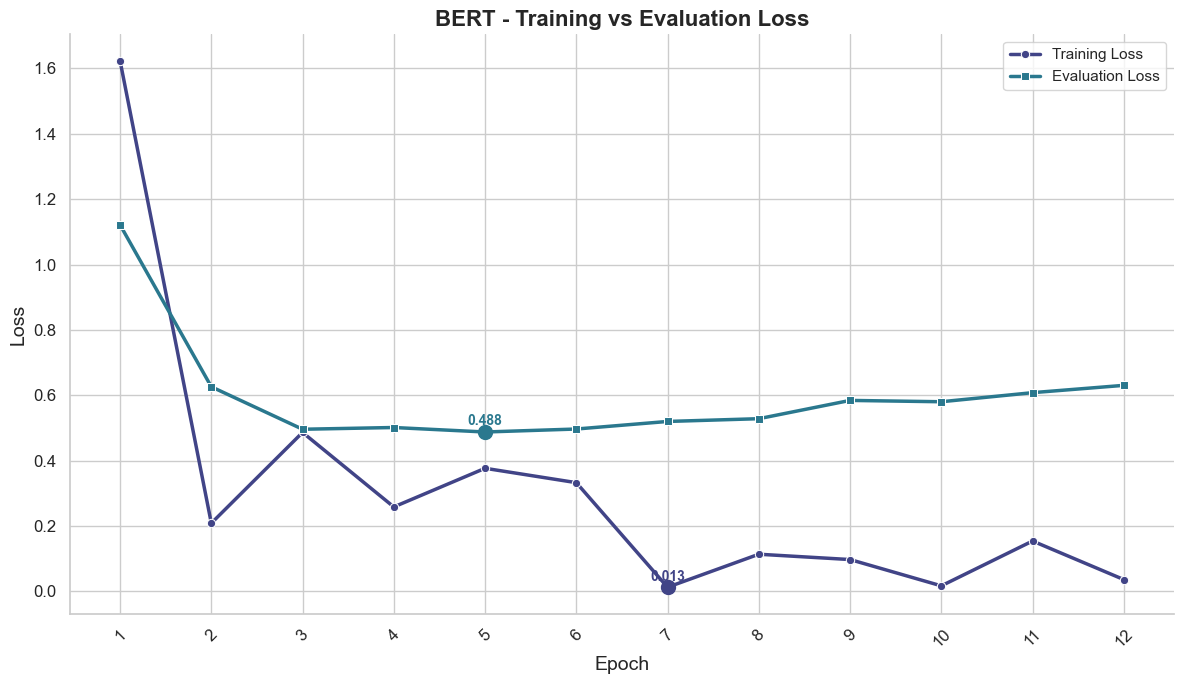

Saved loss plot for GBERT at 'plots/loss_plots/GBERT_loss_plot.png'.


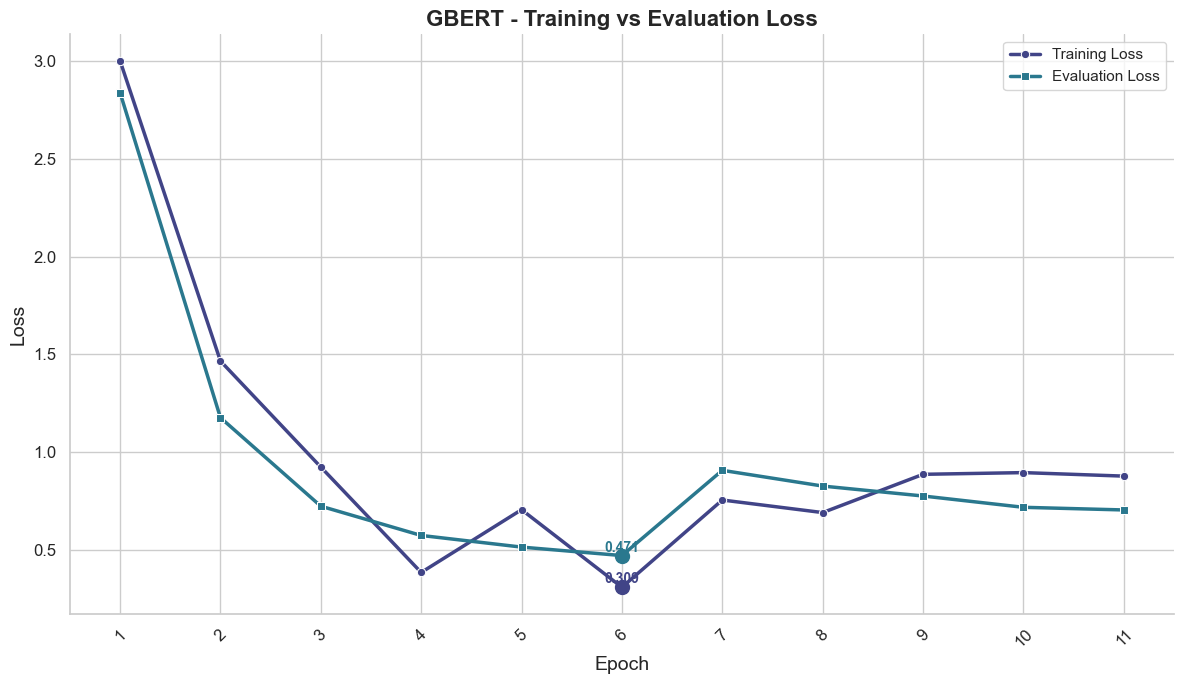

Saved loss plot for XLM-ROBERTa Base at 'plots/loss_plots/XLM-ROBERTa Base_loss_plot.png'.


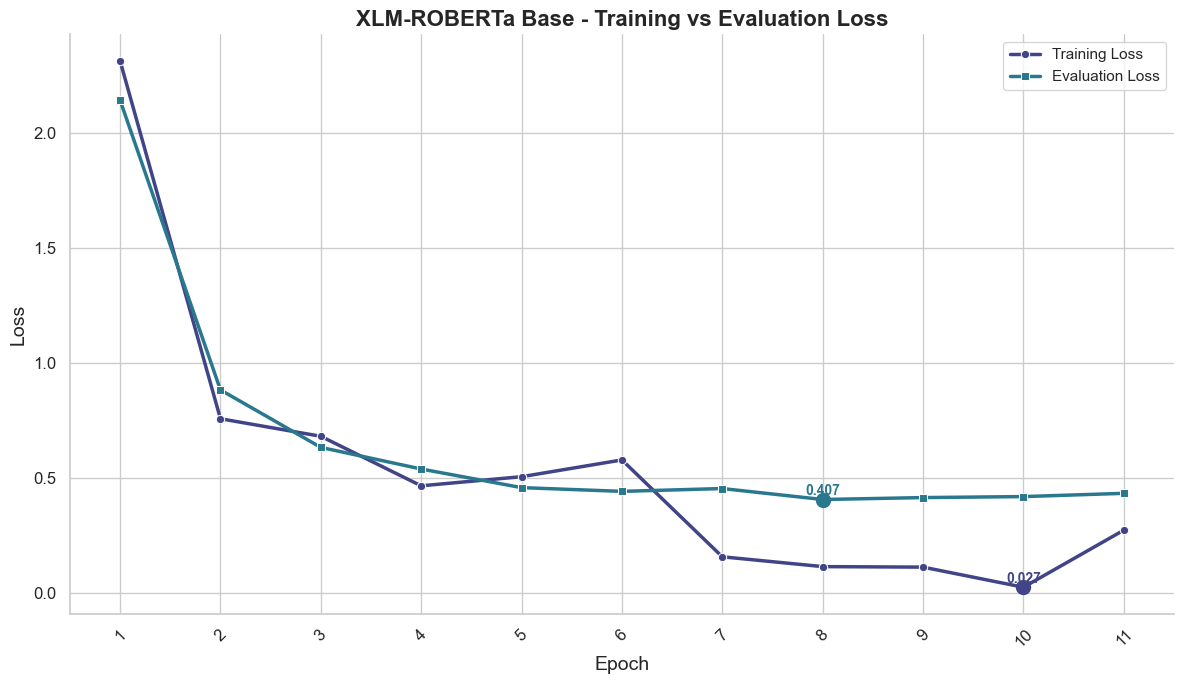

Saved loss plot for XLM-ROBERTa Large at 'plots/loss_plots/XLM-ROBERTa Large_loss_plot.png'.


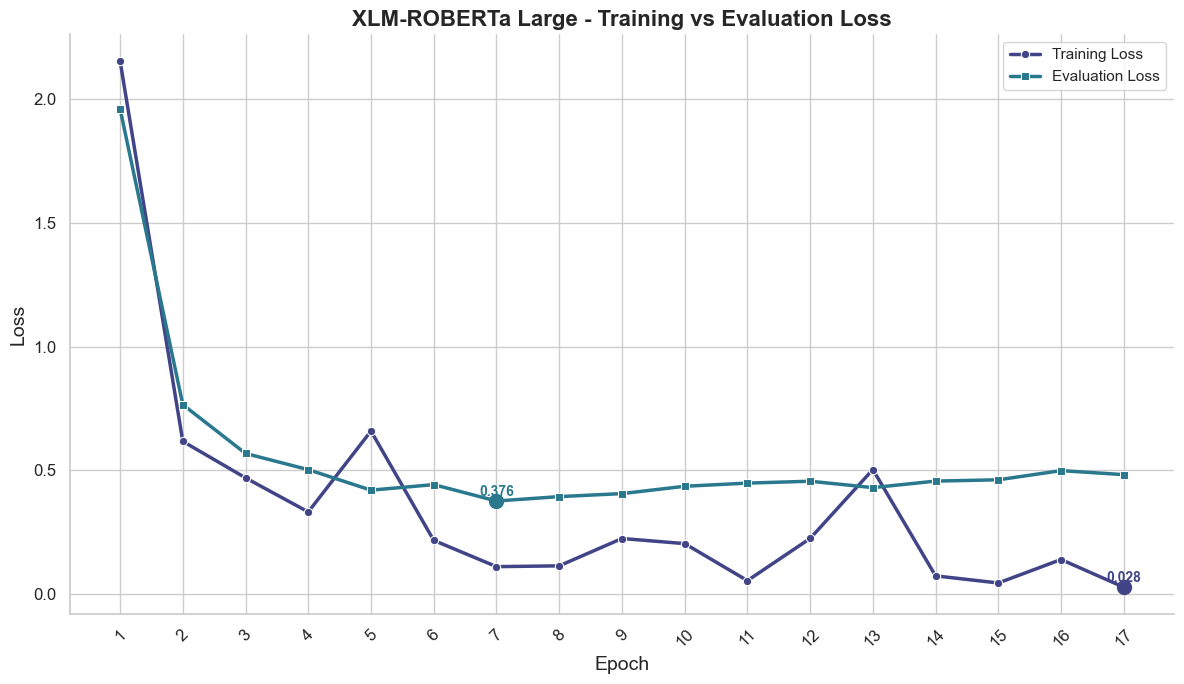

In [32]:
loss_palette = palette[:2]  # First two colors from 'viridis'

# Define colors for metric bar plots based on models
# Ensure that each model has a consistent color across all metrics
model_colors = palette  # Assuming 'viridis' has at least 4 distinct colors

# ----------------------------
# b. Generate and Save Loss Plots
# ----------------------------

# List of models and their corresponding loss DataFrames
loss_plots_info = [
    ('BERT', bert_df),
    ('GBERT', gbert_df),
    ('XLM-ROBERTa Base', xlmroberta_base_df),
    ('XLM-ROBERTa Large', xlm_roberta_large_df)
]

# Iterate and plot
for model_name, df_loss in loss_plots_info:
    plot_and_save_loss(df_loss, model_name, loss_palette, loss_plots_dir)


In [33]:
metric_data = {
    'Model': ['BERT', 'GBERT', 'XLM-ROBERTa Base', 'XLM-ROBERTa Large'],
    'eval_loss': [0.6304094972402121, 0.4706694528427535, 0.434275742451273, 0.48289305128289006],
    'f1_score': [0.906769517223035, 0.8908413205537807, 0.918207208405373, 0.9223896519535938],
    'precision': [0.903046357615894, 0.888004246284501, 0.9144370860927152, 0.9210386151797603],
    'recall': [0.9105235042735043, 0.8936965811965812, 0.9220085470085471, 0.9237446581196581]
}

# Create DataFrame for metric bar plots
df_metrics = pd.DataFrame(metric_data)


/var/folders/d1/z52n225j7jl7n5v2t5tb35n80000gn/T/ipykernel_29099/2585132838.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


Saved metric bar plot for 'eval_loss' at 'plots/metric_plots/eval_loss_comparison.png'.


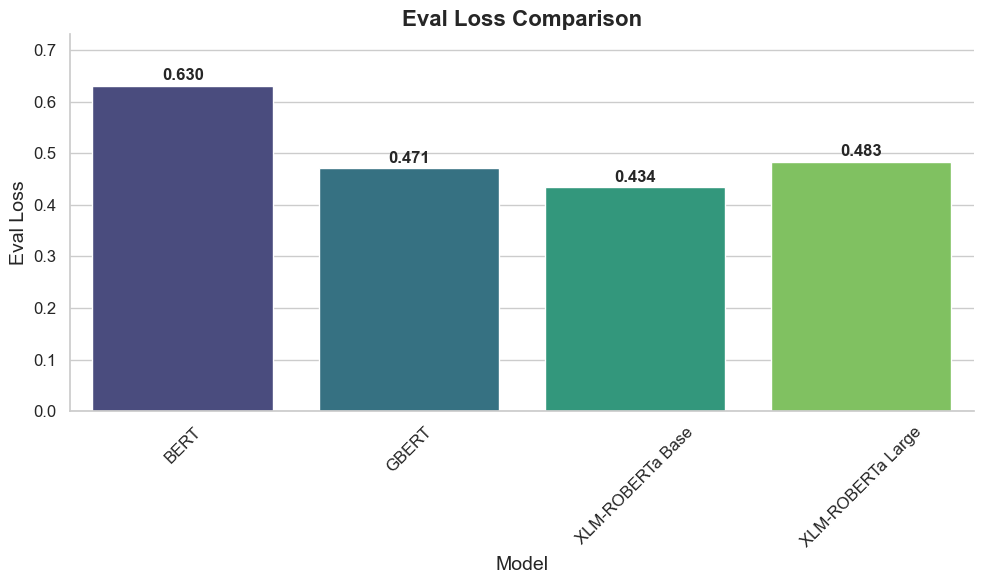

/var/folders/d1/z52n225j7jl7n5v2t5tb35n80000gn/T/ipykernel_29099/2585132838.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


Saved metric bar plot for 'f1_score' at 'plots/metric_plots/f1_score_comparison.png'.


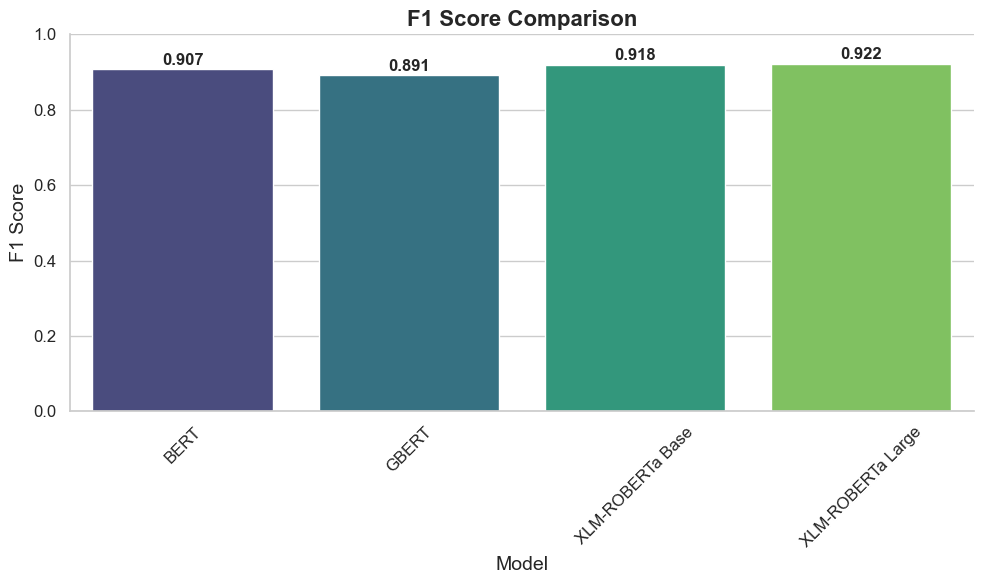

/var/folders/d1/z52n225j7jl7n5v2t5tb35n80000gn/T/ipykernel_29099/2585132838.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


Saved metric bar plot for 'precision' at 'plots/metric_plots/precision_comparison.png'.


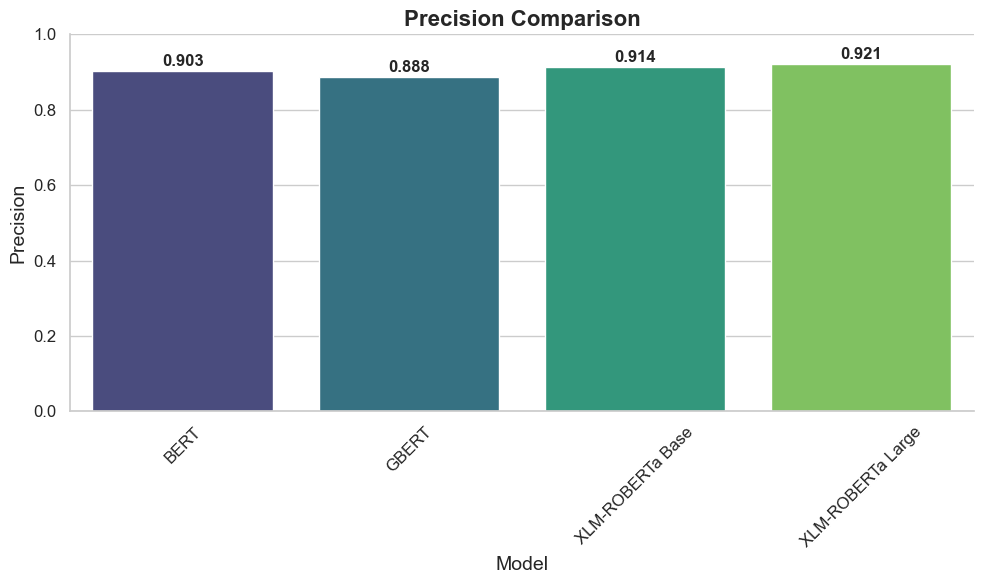

/var/folders/d1/z52n225j7jl7n5v2t5tb35n80000gn/T/ipykernel_29099/2585132838.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


Saved metric bar plot for 'recall' at 'plots/metric_plots/recall_comparison.png'.


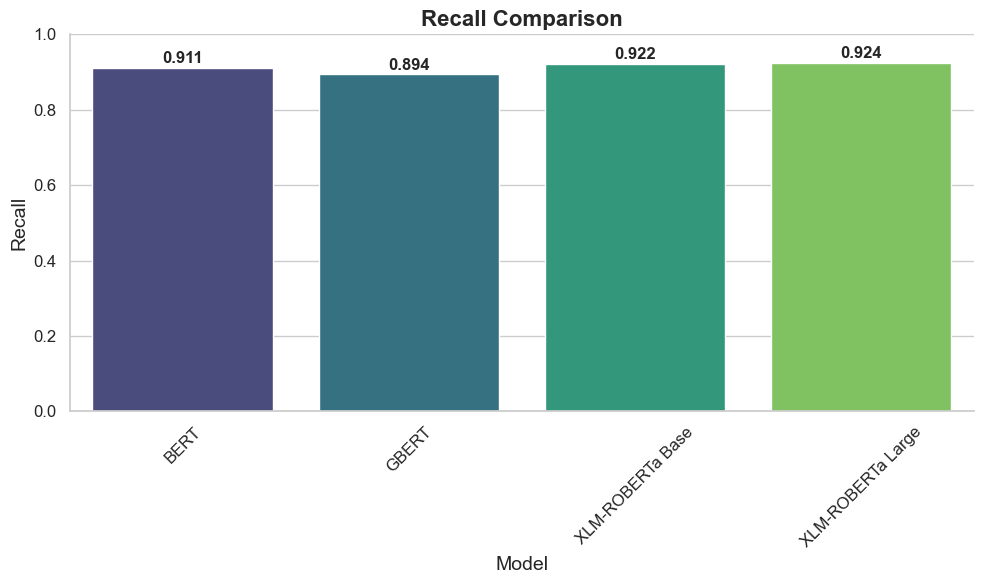

In [34]:
# Define the metrics and their corresponding titles and y-labels
metrics_info = {
    'eval_loss': {
        'title': 'Evaluation Loss Comparison',
        'ylabel': 'Evaluation Loss'
    },
    'f1_score': {
        'title': 'F1 Score Comparison',
        'ylabel': 'F1 Score'
    },
    'precision': {
        'title': 'Precision Comparison',
        'ylabel': 'Precision'
    },
    'recall': {
        'title': 'Recall Comparison',
        'ylabel': 'Recall'
    }
}

# Create a palette dictionary mapping models to colors
# Seaborn expects the palette to be a list of colors corresponding to the order of 'Model'


# Iterate over each metric and plot
for metric, info in metrics_info.items():
    plot_and_save_metric(
        df=df_metrics, 
        metric=metric, 
        palette=palette, 
        save_dir=metric_plots_dir
    )